In [22]:
#Este tutorial está baseado no excelente tutorial de Michaël Defferrard, Nicolas Tremblay em
#https://nbviewer.jupyter.org/github/mdeff/pygsp_tutorial_graphsip/tree/outputs/notebooks/
#Agradeço também Gabi Lewenfus, quem deu idéias e sugestões
#Os erros, pequenos e grandes, de código, estilo e matemática, são exclusivamente meus.

#Este tutorial Aula 4 é 95% idéntico ao do Defferrard e Tremblay em
#https://github.com/mdeff/pygsp_tutorial_graphsip/blob/master/notebooks/05_filters.ipynb


import numpy as np
import matplotlib.pyplot as plt
from pygsp import graphs, filters, utils
import time

#Função a ser usada mais pra frente
def get_approx_filter(c):
	filt_approx = lambda x: np.sum(np.tile(c[1:], (len(x), 1)) * np.cos(np.tile(np.arange(len(c)-1) + 1, (len(x), 1)) * np.transpose(np.tile(np.arccos(x), (len(c) - 1, 1)))), 1) + np.tile(c[0], (len(x), 1)).T * np.cos(0 * np.arccos(x)) / 2
	return filt_approx


/home/kaiserman/miniconda3/envs/scii/lib/python3.13/site-packages/pygsp/plotting.py:610: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  sc = ax.scatter(
/home/kaiserman/miniconda3/envs/scii/lib/python3.13/site-packages/pygsp/graphs/graph.py:955: RuntimeWarning: invalid value encountered in divide
  m = W.dot(self.dw) / self.dw  # Mean degree of adjacent vertices.


Text(0.5, 0, "laplacian's eigenvalues / graph frequencies")

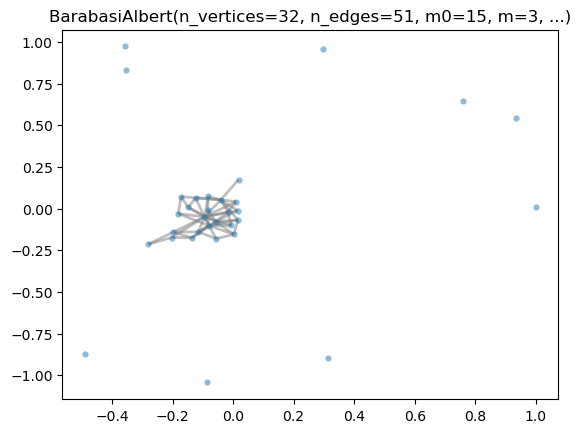

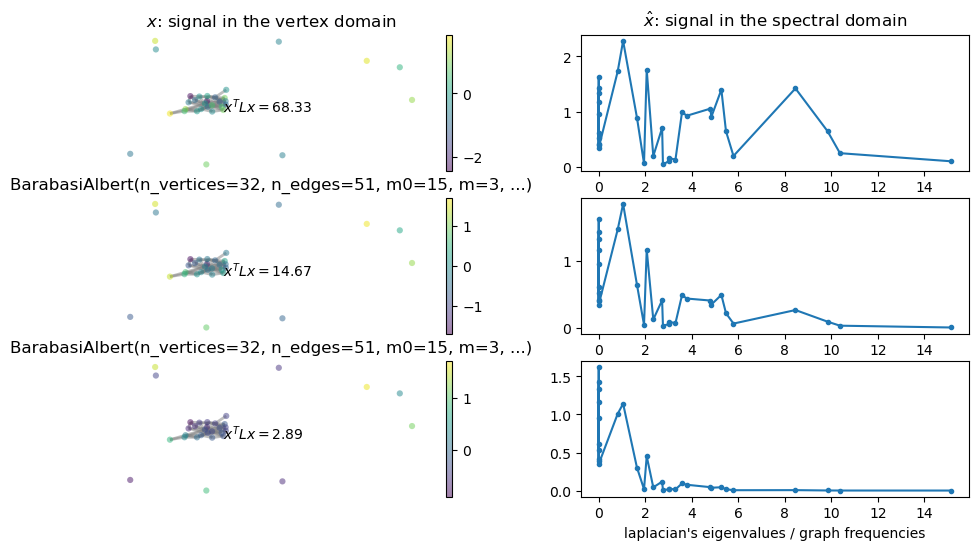

In [ ]:
#Ler na Wikipedia a definição e propriedades básicas de um grafo de Barabasi-Albert
G = graphs.BarabasiAlbert(32,15,3)

G.set_coordinates()
G.plot(vertex_size=20)

G.compute_fourier_basis()

#O vetor taus contém os parámetros para o filtro do calor que usaremos
taus = [0, 3, 10]
fig, axes = plt.subplots(len(taus), 2, figsize=(11, 6))

#Sinal x_0: Normal (0,1) nos vértices
x0 = np.random.RandomState(1).normal(size=G.N)
for i, tau in enumerate(taus):
#Definir o filtro g no grafo G como o do filtro do calor
#Ou seja, no espaço de frequências, multiplicar por $h_{\tau} (\lambda) = \exp (- \tau \lambda)
#Logo, filtro passa-baixa
#Filtrar o sinal x_0 e obter x
#Fazer GFT de x e obter x_hat
#Plotar o valor absoluto dos coeficientes de x_hat
    g = filters.Heat(G, tau)
    x = g.filter(x0).squeeze()
    x_hat = G.gft(x).squeeze()
    
    G.plot_signal(x, vertex_size=20, ax=axes[i, 0])
    axes[i, 0].set_axis_off()
#Ver o valor da forma quadrática Laplaciana em cada caso: qual é o significado?    
    axes[i, 0].text(0, -0.2, '$x^T L x = {:.2f}$'.format(x.T @ G.L @ x))
    
    axes[i, 1].plot(G.e, np.abs(x_hat), '.-')
    
    
axes[0, 0].set_title(r'$x$: signal in the vertex domain')
axes[0, 1].set_title(r'$\hat{x}$: signal in the spectral domain')
axes[-1, 1].set_xlabel("laplacian's eigenvalues / graph frequencies")
#axes[-1, 2].set_xlabel("laplacian's eigenvalues / graph frequencies")

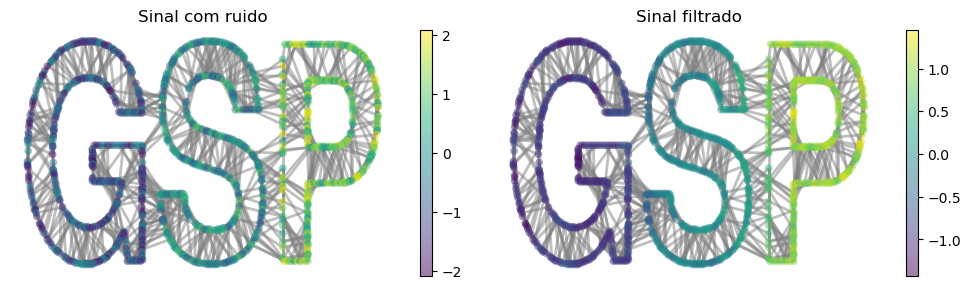

In [24]:
#Vamos a ver como definir um filtro
#Vamos dar a resposta no espaço de frequências e definir o filtro

#Mais outro grafo predefinido do PyGSP
G = graphs.Logo()
G.compute_fourier_basis()

#Aqui definimos a resposta g
#Ver que é o mesmo filtro que em Shuman et al (2013)
#Ou seja, o filtro é um passa-baixa regularizado. Falarei sobre ele na próxima aula
tau = 1
def g(x):
    return 1. / (1. + tau * x)
g = filters.Filter(G, g)

#O sinal x é constante em cada letra
x = np.zeros(G.N)
# print(len(x))

# print(type(G.info))
# print(G.info['idx_g'])

x[G.info['idx_g']] = -1
x[G.info['idx_s']] = 0
x[G.info['idx_p']] = 1

#O ruido é relativamente grande
rs = np.random.RandomState(42)
# x_noisy = x 
x_noisy = x + rs.uniform(-1, 1, size=G.N)

#Filtramos o sinal com ruido pelo nosso filtro, com o "method='exact'"
#Ou seja, o sinal com ruido é levado ao espaço de frequências, aí é filtrado e depois trazido de volta
x_denoised = g.filter(x_noisy, method='exact')

#Comparar os plots dos sinais com ruido e limpado pelo filtro
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
G.plot_signal(x_noisy, vertex_size=30, ax=axes[0])
_ = axes[0].set_title('Sinal com ruido')
axes[0].set_axis_off()
G.plot_signal(x_denoised, vertex_size=30, ax=axes[1])
_ = axes[1].set_title('Sinal filtrado')
axes[1].set_axis_off()
fig.tight_layout()

In [25]:
#Agora vamos aproximar a resposta $g(\lambda) = \frac{1}{1 + \lambda}$ por um polinómio de Chebyshev
#Mas cuidado, nesse caso aproximação era por mínimos quadrados
#Para ver a descrição original de Defferrard e Tremblay, ver em
#https://github.com/mdeff/pygsp_tutorial_graphsip/blob/master/notebooks/05_filters.ipynb



In [26]:
#Grau do polinômio de Chebyshev
m=2 



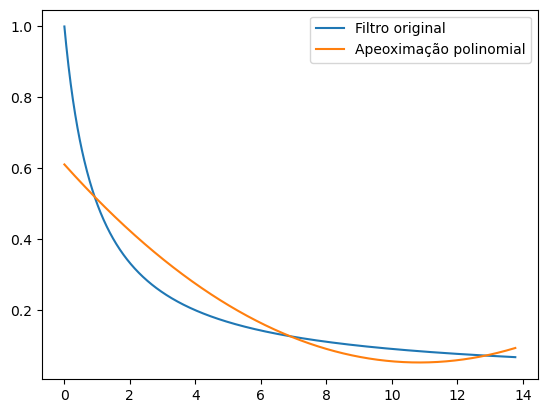

In [27]:
#Filtro c definido através da aproximação de Chebyshev
g = lambda x: 1 / (1 + x)
filt_g = filters.Filter(G, g)
c = filters.approximations.compute_cheby_coeff(filt_g, m=m)

#Comparação do filtro original com a aproximação
filt_approx = get_approx_filter(c)

x = np.arange(0, G.lmax, (G.lmax) / 1000)
plt.figure()
plt.plot(x, g(x))
#plt.hold
plt.plot(x, np.squeeze(filt_approx((x-(G.lmax/2)) / (G.lmax/2))))
plt.legend(['Filtro original', 'Apeoximação polinomial'])



In [29]:
#Medida dos tempos de execucão para comparar performance do filtro exato e aproximado
start_time = time.time()
G.compute_fourier_basis() #just to measure time
x_denoised_exact = filt_g.filter(x_noisy, method='exact')
time_exact_filter = time.time() - start_time
start_time = time.time()
G.estimate_lmax() #just to measure time
x_denoised_cheby = filt_g.filter(x_noisy, method='chebyshev', order=m)
time_cheby_filter = time.time() - start_time

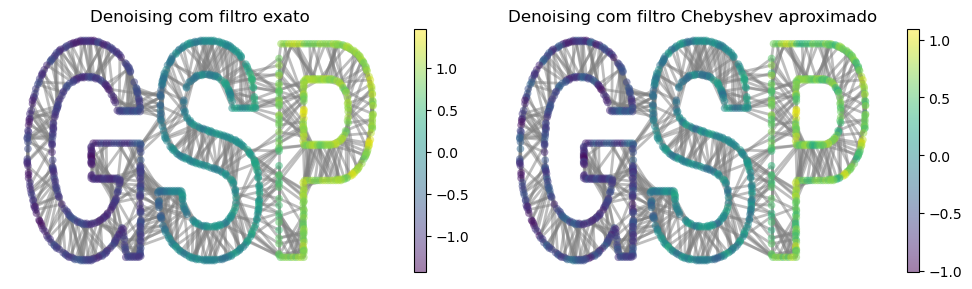

In [30]:
#Comparação dos sinais limpados com filtro exato e Chebyshev aproximado
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
G.plot_signal(x_denoised_exact, vertex_size=30, ax=axes[0])
_ = axes[0].set_title('Denoising com filtro exato')
axes[0].set_axis_off()
G.plot_signal(x_denoised_cheby, vertex_size=30, ax=axes[1])
_ = axes[1].set_title('Denoising com filtro Chebyshev aproximado')
axes[1].set_axis_off()
fig.tight_layout()


In [32]:
print('Erro máximo (no sinal) ' + str(np.max(np.abs(x_denoised_exact-x_denoised_cheby))))
print('Energia media do erro (soma dos quadrados do erro em cada vértice, divido pelo número de vértices) ' + str((np.sum((x_denoised_exact - x_denoised_cheby)**2)/G.N)))

print('Tempo de cálculo com filtro exato ' + str(time_exact_filter))
print('Tempo de cálculo com filtro aproximado ' + str(time_cheby_filter))

Erro máximo (no sinal) 0.47764500696854584
Energia media do erro (soma dos quadrados do erro em cada vértice, divido pelo número de vértices) 0.08805682457309784
Tempo de cálculo com filtro exato 0.002810955047607422
Tempo de cálculo com filtro aproximado 0.0012865066528320312
